In [85]:
import pandas as pd
import os
from pathlib import Path
from sklearn.linear_model import LinearRegression
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import SequenceMatcher
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
import warnings

In [86]:
path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'
df = pd.read_csv(path_data/"data.csv")
df = df.drop(columns=['Unnamed: 0']).query('2021<year | year<=2020').copy()
df['FECHA_NAC'] = pd.to_datetime(df['FECHA_NAC'], errors='coerce')

In [101]:
df_nac_nov2023 = df[(df['FECHA_NAC'].dt.year == 2023) & (df['FECHA_NAC'].dt.month == 11)]
df_nac_nov2019 = df[(df['FECHA_NAC'].dt.year == 2019) & (df['FECHA_NAC'].dt.month == 11)]
df_nac_nov2022 = df[(df['FECHA_NAC'].dt.year == 2022) & (df['FECHA_NAC'].dt.month == 11)]

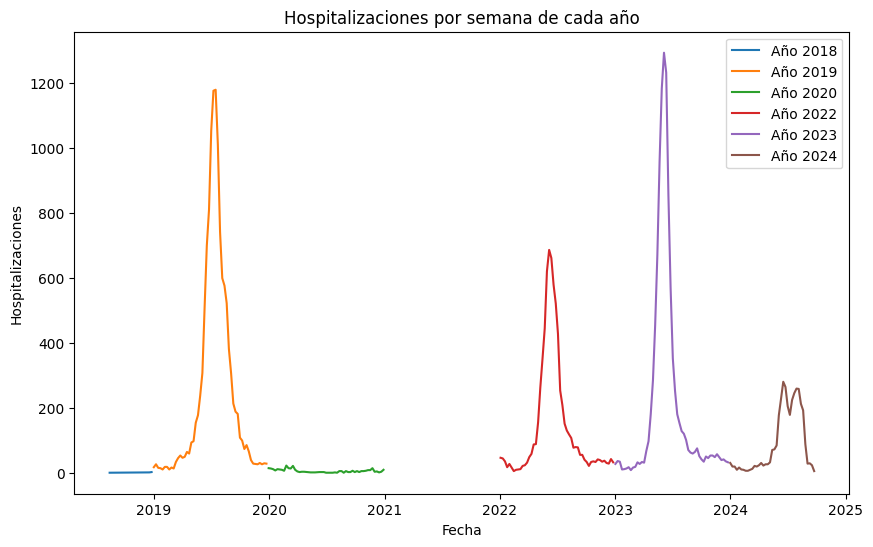

In [102]:
# Agrupar hospitalizaciones por 'year' y 'epiweek', contando el número de hospitalizaciones por semana
hospitalizations_by_week = df.groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')

# Crear la columna de fechas a partir de 'year' y 'epiweek'
hospitalizations_by_week['date'] = pd.to_datetime(hospitalizations_by_week[['year', 'epiweek']].assign(day=1).apply(lambda x: pd.Timestamp.fromisocalendar(x['year'], x['epiweek'], x['day']), axis=1))

# Graficar los datos de hospitalizaciones por año
plt.figure(figsize=(10,6))

# Filtrar por cada año y graficar las hospitalizaciones correspondientes
for year in hospitalizations_by_week['year'].unique():
    yearly_data = hospitalizations_by_week[hospitalizations_by_week['year'] == year]
    plt.plot(yearly_data['date'], yearly_data['hospitalizations'], label=f'Año {year}')

# Añadir etiquetas y título
plt.xlabel('Fecha')
plt.ylabel('Hospitalizaciones')
plt.title('Hospitalizaciones por semana de cada año')
plt.legend()

# Mostrar gráfico
plt.show()


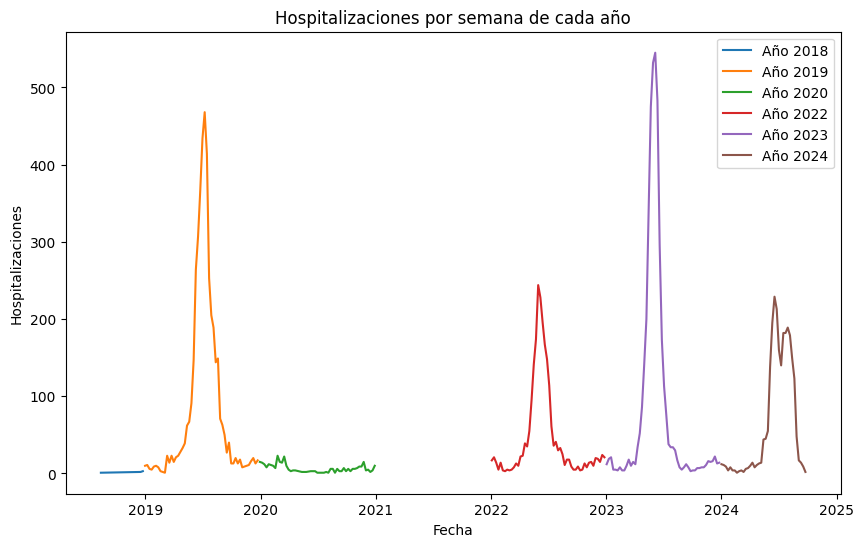

In [104]:
# Agrupar hospitalizaciones por 'year' y 'epiweek', contando el número de hospitalizaciones por semana
hospitalizations_by_week = df[df['elegibilidad'] != df['year']].groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')

# Crear la columna de fechas a partir de 'year' y 'epiweek'
hospitalizations_by_week['date'] = pd.to_datetime(hospitalizations_by_week[['year', 'epiweek']].assign(day=1).apply(lambda x: pd.Timestamp.fromisocalendar(x['year'], x['epiweek'], x['day']), axis=1))

# Graficar los datos de hospitalizaciones por año
plt.figure(figsize=(10,6))

# Filtrar por cada año y graficar las hospitalizaciones correspondientes
for year in hospitalizations_by_week['year'].unique():
    yearly_data = hospitalizations_by_week[hospitalizations_by_week['year'] == year]
    plt.plot(yearly_data['date'], yearly_data['hospitalizations'], label=f'Año {year}')

# Añadir etiquetas y título
plt.xlabel('Fecha')
plt.ylabel('Hospitalizaciones')
plt.title('Hospitalizaciones por semana de cada año')
plt.legend()

# Mostrar gráfico
plt.show()

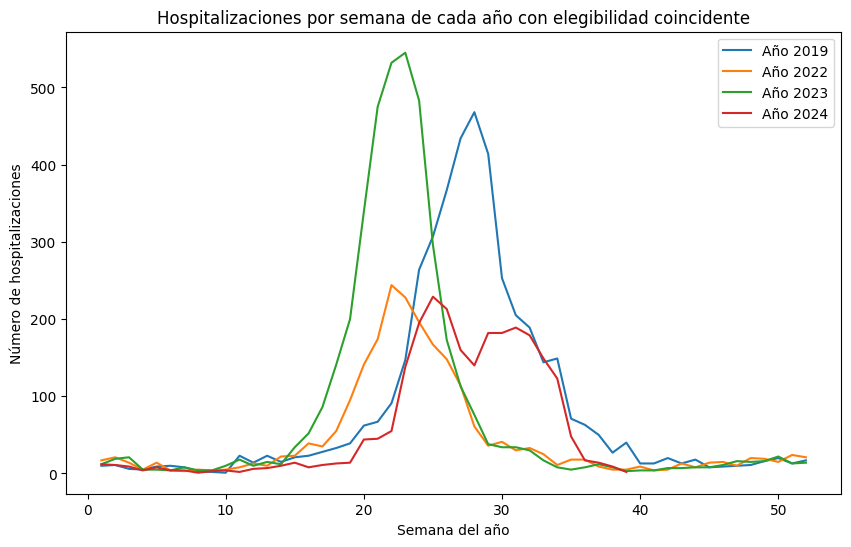

In [46]:
import matplotlib.pyplot as plt

# Asegúrate de que las columnas 'year', 'epiweek' y 'elegibilidad' están correctas
hospitalizations_by_week = df[df['elegibilidad'] != df['year']].groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')

# Crear el gráfico
plt.figure(figsize=(10,6))

# Graficar hospitalizaciones por cada año con elegibilidad correspondiente
for year in hospitalizations_by_week['year'].unique():
    yearly_data = hospitalizations_by_week[hospitalizations_by_week['year'] == year]
    plt.plot(yearly_data['epiweek'], yearly_data['hospitalizations'], label=f'Año {year}')

# Añadir etiquetas y título
plt.xlabel('Semana del año')
plt.ylabel('Número de hospitalizaciones')
plt.title('Hospitalizaciones por semana de cada año con elegibilidad coincidente')
plt.legend()

# Mostrar el gráfico
plt.show()


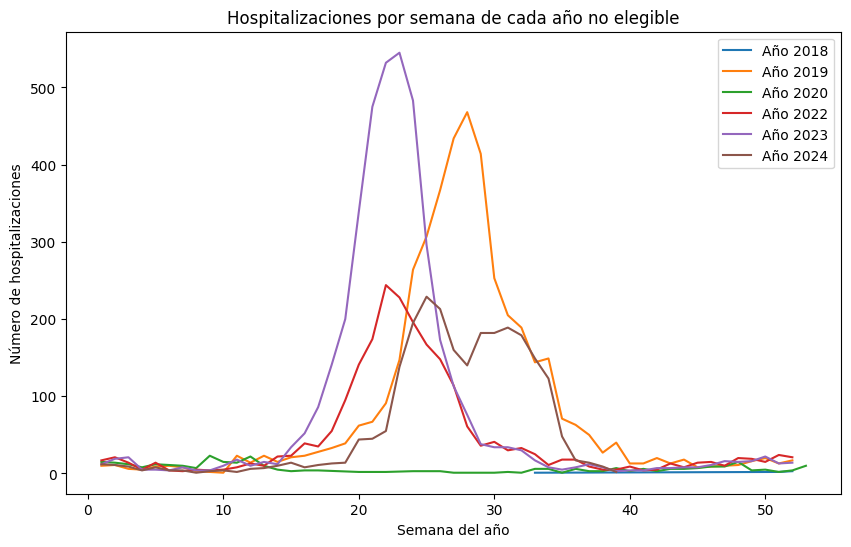

In [149]:
# Asegúrate de que las columnas 'year', 'epiweek' y 'elegibilidad' están correctas
hospitalizations_by_week = df[df['elegibilidad'] != df['year']].groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')

# Crear el gráfico
plt.figure(figsize=(10,6))

# Graficar hospitalizaciones por cada año con elegibilidad correspondiente
for year in hospitalizations_by_week['year'].unique():
    yearly_data = hospitalizations_by_week[hospitalizations_by_week['year'] == year]
    plt.plot(yearly_data['epiweek'], yearly_data['hospitalizations'], label=f'Año {year}')

# Añadir etiquetas y título
plt.xlabel('Semana del año')
plt.ylabel('Número de hospitalizaciones')
plt.title('Hospitalizaciones por semana de cada año no elegible')
plt.legend()

# Mostrar el gráfico
plt.show()

Tamaño de X_train: 35
Tamaño de y_train: 35


C:\Users\ntrig\AppData\Local\Temp\ipykernel_19032\2931503315.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hospitalizations_2022['epiweek_shifted'] = hospitalizations_2022['epiweek'] + 4


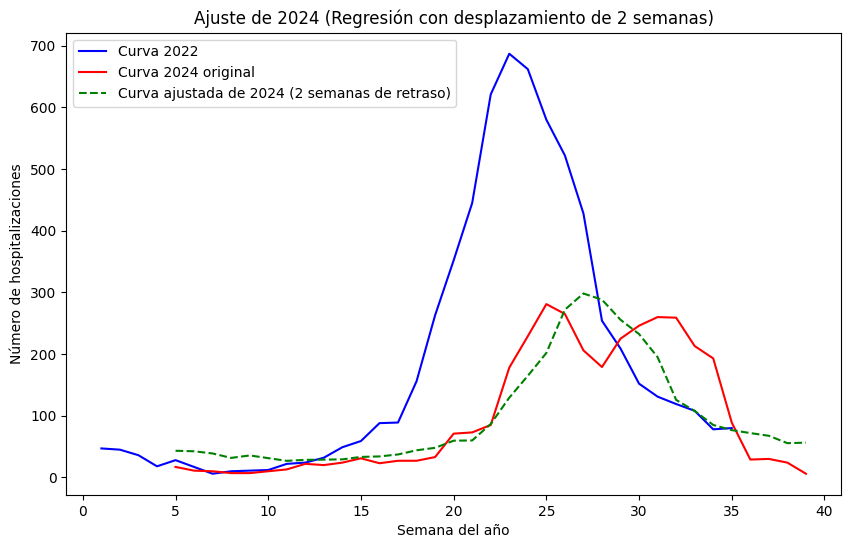

In [144]:
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt

# **Primera parte: Ajustar modelo de regresión lineal con 2 semanas de retraso**
# Filtrar hospitalizaciones de 2022
hospitalizations_2022 = hospitalizations_by_week[hospitalizations_by_week['year'] == 2022]
# Filtrar hospitalizaciones de 2024 disponibles hasta la fecha actual
hospitalizations_2024 = hospitalizations_by_week[hospitalizations_by_week['year'] == 2024]

# Desplazar 2 semanas hacia adelante en 2022
hospitalizations_2022['epiweek_shifted'] = hospitalizations_2022['epiweek'] + 4

# Asegurarse de que las semanas desplazadas de 2022 coinciden con las semanas de 2024
# Solo seleccionar semanas donde haya datos tanto en 2022 (desplazado) como en 2024
epiweeks_2024 = hospitalizations_2024['epiweek'].unique()  # Obtener las semanas disponibles de 2024
hospitalizations_2022_train = hospitalizations_2022[hospitalizations_2022['epiweek_shifted'].isin(epiweeks_2024)]  # Filtrar semanas de 2022 desplazadas

# Asegurarse de que también se limitan las semanas de 2024 para coincidir con las semanas de 2022 desplazadas
hospitalizations_2024_train = hospitalizations_2024[hospitalizations_2024['epiweek'].isin(hospitalizations_2022_train['epiweek_shifted'])]

# Entrenar modelo de regresión lineal con las semanas desplazadas de 2022 y 2024
X_train = hospitalizations_2022_train['hospitalizations'].values.reshape(-1, 1)  # Hospitalizaciones de 2022 desplazadas
y_train = hospitalizations_2024_train['hospitalizations'].values  # Hospitalizaciones de 2024

# Verificar tamaños antes de ajustar el modelo
print(f"Tamaño de X_train: {len(X_train)}")
print(f"Tamaño de y_train: {len(y_train)}")

# Ajustar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Predecir la curva ajustada de 2024 usando el modelo con 2 semanas de retraso
predicted_2024 = model.predict(X_train)

# Graficar las 3 curvas (2022, 2024 y ajustada de 2024)
plt.figure(figsize=(10,6))
# Curva original de 2022 (no desplazada)
plt.plot(hospitalizations_2022_train['epiweek'], hospitalizations_2022_train['hospitalizations'], label='Curva 2022', color='blue')
# Curva original de 2024 (hasta la fecha actual)
plt.plot(hospitalizations_2024_train['epiweek'], hospitalizations_2024_train['hospitalizations'], label='Curva 2024 original', color='red')
# Curva ajustada de 2024 (regresión lineal con 2 semanas de retraso)
plt.plot(hospitalizations_2022_train['epiweek_shifted'], predicted_2024, label='Curva ajustada de 2024 (2 semanas de retraso)', linestyle='--', color='green')

# Añadir etiquetas y título
plt.xlabel('Semana del año')
plt.ylabel('Número de hospitalizaciones')
plt.title('Ajuste de 2024 (Regresión con desplazamiento de 2 semanas)')
plt.legend()
plt.show()




C:\Users\ntrig\AppData\Local\Temp\ipykernel_19032\3916965122.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hospitalizations_2022_extended['epiweek_shifted'] = hospitalizations_2022_extended['epiweek'] + 2
C:\Users\ntrig\AppData\Local\Temp\ipykernel_19032\3916965122.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hospitalizations_2022_extended['epiweek_shifted'] = hospitalizations_2022_extended['epiweek_shifted'].apply(lambda x: x if x <= 52 else 52)
C:\Users\ntrig\AppData\Local\Temp\ipykernel_1903

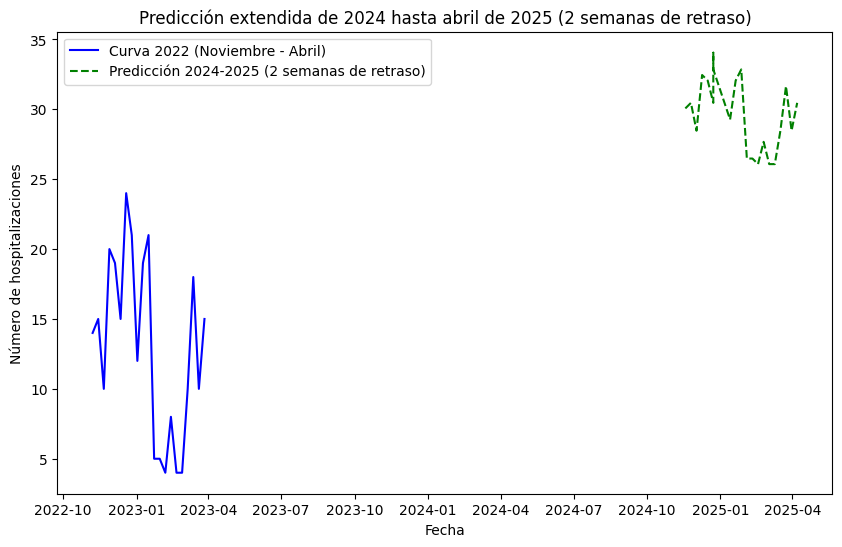

In [154]:
hospitalizations_2022_extended = hospitalizations_by_week[((hospitalizations_by_week['year'] == 2022) & (hospitalizations_by_week['epiweek'] >= 45)) | 
                                                          ((hospitalizations_by_week['year'] == 2023) & (hospitalizations_by_week['epiweek'] <= 13))]

# Desplazar las semanas hacia adelante en 2022 y 2023 (2 semanas)
hospitalizations_2022_extended['epiweek_shifted'] = hospitalizations_2022_extended['epiweek'] + 2

# Limitar las semanas a un máximo de 52 (semana ISO válida)
hospitalizations_2022_extended['epiweek_shifted'] = hospitalizations_2022_extended['epiweek_shifted'].apply(lambda x: x if x <= 52 else 52)

# Usar los datos de 2022 desplazados para predecir desde la semana actual hasta la semana 54 de 2024
X_future = hospitalizations_2022_extended['hospitalizations'].values.reshape(-1, 1)
hospitalizations_2022_extended['hospitalizations_pred'] = model.predict(X_future)  # Predecir usando el modelo entrenado

# Crear las fechas de la predicción para 2024 hasta la semana 18 de 2025
hospitalizations_2022_extended['year_pred'] = hospitalizations_2022_extended.apply(lambda row: 2024 if row['epiweek'] >= 44 else 2025, axis=1)
hospitalizations_2022_extended['date_pred'] = pd.to_datetime(hospitalizations_2022_extended[['year_pred', 'epiweek_shifted']].assign(day=1).apply(lambda x: pd.Timestamp.fromisocalendar(x['year_pred'], int(x['epiweek_shifted']), x['day']), axis=1))

# Ahora también creamos las fechas para las hospitalizaciones de 2022
hospitalizations_2022_extended['date_2022'] = pd.to_datetime(hospitalizations_2022_extended[['year', 'epiweek']].assign(day=1).apply(lambda x: pd.Timestamp.fromisocalendar(x['year'], int(x['epiweek']), x['day']), axis=1))

# Graficar la predicción extendida hasta abril de 2025
plt.figure(figsize=(10,6))
# Curva original de 2022 (Noviembre 2022 - Abril 2023)
plt.plot(hospitalizations_2022_extended['date_2022'], hospitalizations_2022_extended['hospitalizations'], label='Curva 2022 (Noviembre - Abril)', color='blue')
# Curva predicha de 2024 hasta abril 2025 (con desplazamiento)
plt.plot(hospitalizations_2022_extended['date_pred'], hospitalizations_2022_extended['hospitalizations_pred'], label='Predicción 2024-2025 (2 semanas de retraso)', color='green', linestyle='--')

# Etiquetas y título
plt.xlabel('Fecha')
plt.ylabel('Número de hospitalizaciones')
plt.title('Predicción extendida de 2024 hasta abril de 2025 (2 semanas de retraso)')
plt.legend()
plt.show()


In [146]:
hospitalizations_2022_extended

,year,epiweek,hospitalizations,epiweek_shifted,hospitalizations_pred,year_pred,date_pred,date_2022
146,2022,45,42,47,41.219305,2024,2024-11-18,2022-11-07
147,2022,46,40,48,40.422394,2024,2024-11-25,2022-11-14
148,2022,47,35,49,38.430116,2024,2024-12-02,2022-11-21
149,2022,48,38,50,39.625483,2024,2024-12-09,2022-11-28
150,2022,49,31,51,36.836294,2024,2024-12-16,2022-12-05
151,2022,50,29,52,36.039383,2024,2024-12-23,2022-12-12
152,2022,51,43,52,41.617761,2024,2024-12-23,2022-12-19
153,2022,52,33,52,37.633205,2024,2024-12-23,2022-12-26
154,2023,1,28,3,35.640927,2025,2025-01-13,2023-01-02
155,2023,2,37,4,39.227027,2025,2025-01-20,2023-01-09


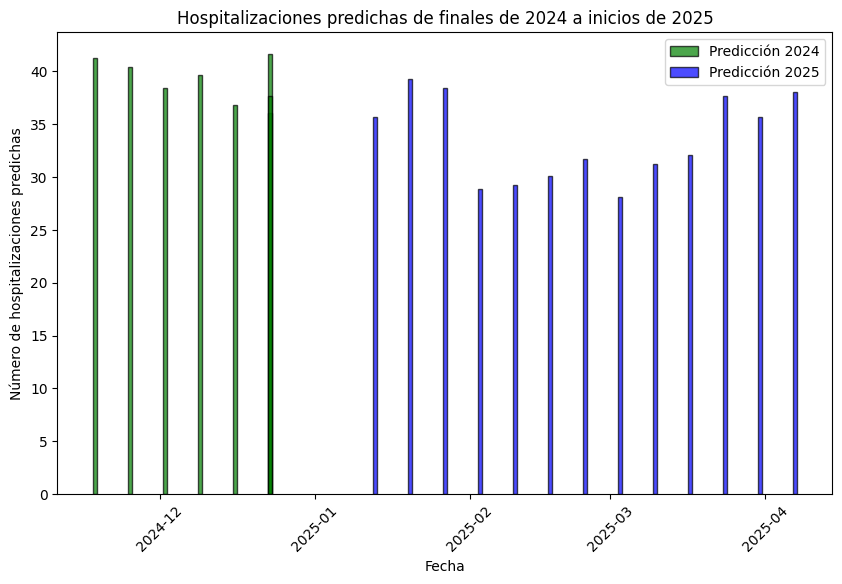

In [143]:
import matplotlib.pyplot as plt

# Filtrar semanas de 2024 (44 a 54) y 2025 (1 a 18)
hospitalizations_pred_2024 = hospitalizations_2022_extended[hospitalizations_2022_extended['year_pred'] == 2024]
hospitalizations_pred_2025 = hospitalizations_2022_extended[hospitalizations_2022_extended['year_pred'] == 2025]

# Crear el gráfico con fechas reales en el eje x
plt.figure(figsize=(10,6))

# Graficar las hospitalizaciones predichas para 2024
plt.bar(hospitalizations_pred_2024['date_pred'], hospitalizations_pred_2024['hospitalizations_pred'], color='green', edgecolor='black', alpha=0.7, label='Predicción 2024')

# Graficar las hospitalizaciones predichas para 2025
plt.bar(hospitalizations_pred_2025['date_pred'], hospitalizations_pred_2025['hospitalizations_pred'], color='blue', edgecolor='black', alpha=0.7, label='Predicción 2025')

# Añadir etiquetas y título
plt.xlabel('Fecha')
plt.ylabel('Número de hospitalizaciones predichas')
plt.title('Hospitalizaciones predichas de finales de 2024 a inicios de 2025')
plt.xticks(rotation=45)  # Rotar etiquetas del eje X para que se vean mejor
plt.legend()

# Mostrar el gráfico
plt.show()




In [150]:
# Filtrar solo los bebés nacidos en noviembre de 2022
df_nov2022 = df[(df['FECHA_NAC'].dt.year == 2022) & (df['FECHA_NAC'].dt.month == 11)]
# Agrupar las hospitalizaciones por semana y año para este subconjunto
hospitalizations_by_week_nov2022 = df_nov2022.groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')
# Usamos el mismo código que antes para predecir de finales de 2024 a inicios de 2025

In [151]:
hospitalizations_by_week_nov2022

,year,epiweek,hospitalizations
0,2022,45,1
1,2022,46,1
2,2022,47,2
3,2022,48,5
4,2022,49,5
...,...,...,...
63,2024,33,3
64,2024,34,2
65,2024,35,3
66,2024,36,1


In [153]:
hospitalizations_2022_nov

,year,epiweek,hospitalizations
0,2022,45,1
1,2022,46,1
2,2022,47,2
3,2022,48,5
4,2022,49,5
5,2022,50,3
6,2022,51,9
7,2022,52,7
8,2023,1,6
9,2023,2,7


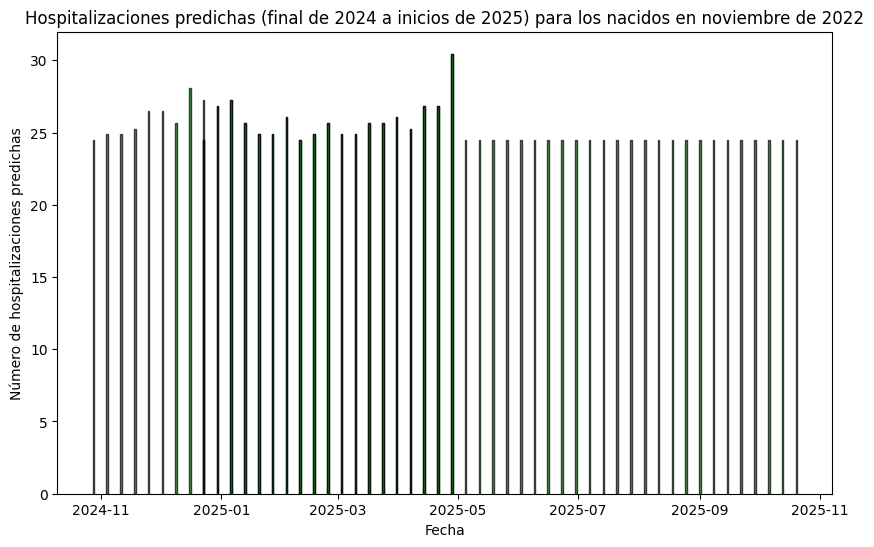

In [156]:
import matplotlib.pyplot as plt
import pandas as pd

# Filtrar hospitalizaciones de este grupo específico en 2022
hospitalizations_2022_nov = hospitalizations_by_week_nov2022[((hospitalizations_by_week_nov2022['year'] == 2022) & (hospitalizations_by_week_nov2022['epiweek'] >= 44)) | 
                                                             ((hospitalizations_by_week_nov2022['year'] == 2023) & (hospitalizations_by_week_nov2022['epiweek'] <= 18))]

# Crear un rango de semanas hasta la semana 18 de 2025
weeks_extended_nov = pd.DataFrame({'epiweek': np.arange(1, 55)})
weeks_extended_2025_nov = pd.DataFrame({'epiweek': np.arange(1, 19)})
weeks_extended_nov = pd.concat([weeks_extended_nov, weeks_extended_2025_nov], ignore_index=True)

# Asegurarse de que las semanas coinciden
merged_data_nov = weeks_extended_nov.merge(hospitalizations_2022_nov, on='epiweek', how='left')

# Definir las variables de entrada y salida
X_nov = merged_data_nov['hospitalizations'].fillna(0).values.reshape(-1, 1)  # Llenar semanas faltantes con ceros

# Predecir usando el modelo entrenado anteriormente
predicted_2024_2025_nov = model.predict(X_nov)

# Limitar semanas a un máximo de 52
merged_data_nov['epiweek'] = merged_data_nov['epiweek'].apply(lambda x: x if x <= 52 else 52)

# Crear las fechas de la predicción
merged_data_nov['year_pred'] = merged_data_nov.apply(lambda row: 2024 if row['epiweek'] >= 44 else 2025, axis=1)
merged_data_nov['date_pred'] = pd.to_datetime(merged_data_nov[['year_pred', 'epiweek']].assign(day=1).apply(lambda x: pd.Timestamp.fromisocalendar(x['year_pred'], int(x['epiweek']), x['day']), axis=1))

# Graficar las hospitalizaciones predichas para este grupo
plt.figure(figsize=(10,6))
plt.bar(merged_data_nov['date_pred'], predicted_2024_2025_nov, color='green', edgecolor='black', alpha=0.7)

# Añadir etiquetas y título
plt.xlabel('Fecha')
plt.ylabel('Número de hospitalizaciones predichas')
plt.title('Hospitalizaciones predichas (final de 2024 a inicios de 2025) para los nacidos en noviembre de 2022')

# Mostrar el gráfico
plt.show()
